## PHASE 4: EXPLORATORY DATA ANALYSIS

In [2]:
#Viewing the first 5 rows for each of the 3 dataset
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

files = ['deduped_dot1.csv', 'deduped_dot2.csv', 'deduped_dot3.csv']

for file in files:
    print(f"\n Preview of {file}:")
    df = pd.read_csv(file, nrows=5)
    display(df.style.set_table_attributes("style='display:inline'").set_caption(file))





 Preview of deduped_dot1.csv:


,CANPROV,COMMODITY2,CONTCODE,COUNTRY,DEPE,DF,DISAGMOT,FREIGHT_CHARGES,MEXSTATE,MONTH,SHIPWT,SOURCE_FILE,TRDTYPE,USASTATE,VALUE,YEAR
0,XB,Unknown,X,1220,115.000000,2.000000,5,67,Unknown,4,0,dot1_0420.csv,1,AK,4660,2020
1,XO,Unknown,X,1220,901.000000,1.000000,5,282,Unknown,4,0,dot1_0420.csv,1,AK,14360,2020
2,Unknown,Unknown,0,2010,nan,1.000000,1,0,XX,4,24971000,dot1_0420.csv,1,AK,4293733,2020
3,XA,Unknown,X,1220,nan,1.000000,3,563,Unknown,4,443,dot1_0420.csv,1,AK,28283,2020
4,XA,Unknown,X,1220,nan,2.000000,3,538,Unknown,4,69,dot1_0420.csv,1,AK,29848,2020



 Preview of deduped_dot2.csv:


,CANPROV,COMMODITY2,CONTCODE,COUNTRY,DEPE,DF,DISAGMOT,FREIGHT_CHARGES,MEXSTATE,MONTH,SHIPWT,SOURCE_FILE,TRDTYPE,USASTATE,VALUE,YEAR
0,Unknown,2,0,2010,nan,1.000000,5,0,NL,4,0,dot2_0420.csv,1,AK,22370,2020
1,XB,3,X,1220,nan,1.000000,1,1482,Unknown,4,24698,dot2_0420.csv,1,AK,108133,2020
2,XC,3,X,1220,nan,1.000000,1,15864,Unknown,4,99790,dot2_0420.csv,1,AK,809104,2020
3,XC,3,X,1220,nan,1.000000,5,17546,Unknown,4,0,dot2_0420.csv,1,AK,887888,2020
4,XO,3,X,1220,nan,1.000000,5,1665,Unknown,4,0,dot2_0420.csv,1,AK,76006,2020



 Preview of deduped_dot3.csv:


,CANPROV,COMMODITY2,CONTCODE,COUNTRY,DEPE,DF,DISAGMOT,FREIGHT_CHARGES,MEXSTATE,MONTH,SHIPWT,SOURCE_FILE,TRDTYPE,USASTATE,VALUE,YEAR
0,Unknown,9,X,1220,101.000000,2.000000,5,56,Unknown,4,0,dot3_0420.csv,1,Unknown,2864,2020
1,Unknown,19,X,1220,101.000000,1.000000,5,241,Unknown,4,0,dot3_0420.csv,1,Unknown,12690,2020
2,Unknown,20,X,1220,101.000000,1.000000,5,131,Unknown,4,0,dot3_0420.csv,1,Unknown,6699,2020
3,Unknown,25,X,1220,101.000000,1.000000,6,506,Unknown,4,0,dot3_0420.csv,1,Unknown,25854,2020
4,Unknown,28,X,1220,101.000000,2.000000,5,313,Unknown,4,0,dot3_0420.csv,1,Unknown,16007,2020


In [3]:
#Summary Statistics for each of the 3 dataset
import pandas as pd
import numpy as np
from IPython.display import display

# Files and columns
files = {
    "DOT1": "deduped_dot1.csv",
    "DOT2": "deduped_dot2.csv",
    "DOT3": "deduped_dot3.csv"
}
numeric_cols = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES', 'DF', 'MONTH', 'YEAR']
dtypes = {col: 'float64' for col in numeric_cols}
chunk_size = 500_000

def compute_summary_stats(file_path):
    stats = {
        col: {'sum': 0, 'sumsq': 0, 'count': 0, 'min': float('inf'), 'max': float('-inf')}
        for col in numeric_cols
    }

    for chunk in pd.read_csv(file_path, usecols=numeric_cols, dtype=dtypes, chunksize=chunk_size):
        for col in numeric_cols:
            data = chunk[col].dropna()
            stats[col]['sum'] += data.sum()
            stats[col]['sumsq'] += (data ** 2).sum()
            stats[col]['count'] += data.count()
            stats[col]['min'] = min(stats[col]['min'], data.min())
            stats[col]['max'] = max(stats[col]['max'], data.max())

    summary = {}
    for col, stat in stats.items():
        mean = stat['sum'] / stat['count'] if stat['count'] else np.nan
        var = (stat['sumsq'] - (stat['sum'] ** 2) / stat['count']) / stat['count'] if stat['count'] else np.nan
        std = np.sqrt(var) if not np.isnan(var) else np.nan

        summary[col] = {
            'count': stat['count'],
            'mean': mean,
            'std': std,
            'min': stat['min'],
            'max': stat['max']
        }

    return pd.DataFrame(summary).T

# Run for each dataset
for label, file in files.items():
    print(f"\n Summary Statistics for {label}:")
    try:
        df_summary = compute_summary_stats(file)
        display(df_summary.round(2))
    except FileNotFoundError:
        print(f" File '{file}' not found. Please ensure it exists in your directory.")



 Summary Statistics for DOT1:


,count,mean,std,min,max
VALUE,7993825.0,4186614.93,44780890.49,0.0,4.951806e+09
SHIPWT,7993825.0,1756725.10,46840262.04,0.0,8.563936e+09
FREIGHT_CHARGES,7993825.0,56096.07,1150826.92,0.0,2.275531e+08
DF,4966556.0,1.33,0.47,1.0,2.000000e+00
MONTH,7993825.0,4.63,2.91,1.0,1.200000e+01
YEAR,7993825.0,2021.58,1.06,2020.0,2.024000e+03



 Summary Statistics for DOT2:


,count,mean,std,min,max
VALUE,21905694.0,1527779.36,24618750.36,1.0,5.595625e+09
SHIPWT,21905694.0,641064.05,29397634.22,0.0,8.563936e+09
FREIGHT_CHARGES,21905694.0,20470.58,751394.08,0.0,2.487214e+08
DF,15209785.0,1.33,0.47,1.0,2.000000e+00
MONTH,21905694.0,4.62,2.91,1.0,1.200000e+01
YEAR,21905694.0,2021.58,1.06,2020.0,2.024000e+03



 Summary Statistics for DOT3:


,count,mean,std,min,max
VALUE,4994866.0,6660767.47,56409286.91,0.0,5.331094e+09
SHIPWT,4994866.0,2794722.83,62177275.91,0.0,9.068700e+09
FREIGHT_CHARGES,4994866.0,89244.94,1559956.38,0.0,2.389452e+08
DF,2988510.0,1.37,0.48,1.0,2.000000e+00
MONTH,4994866.0,4.62,2.92,1.0,1.200000e+01
YEAR,4994865.0,2021.56,1.05,2020.0,2.024000e+03


Univariate Analysis

In [4]:
# Distribution of categorical columns
def plot_top_countries(file_path, label, top_n=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    country_counts = {}
    for chunk in pd.read_csv(file_path, usecols=['COUNTRY'], dtype=str, chunksize=500_000):
        counts = chunk['COUNTRY'].value_counts()
        for k, v in counts.items():
            country_counts[k] = country_counts.get(k, 0) + v

    s = pd.Series(country_counts).sort_values(ascending=False).head(top_n)
    df = s.reset_index()
    df.columns = ['COUNTRY', 'Count']

    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=df, x='Count', y='COUNTRY', hue='COUNTRY', palette='Oranges_d', legend=False)

    for i, (val, name) in enumerate(zip(df['Count'], df['COUNTRY'])):
        plt.text(val + max(df['Count']) * 0.01, i, f"{val:,}", va='center', fontsize=11, fontweight='bold')

    plt.title(f"Top {top_n} COUNTRY Codes in {label}", fontsize=16, fontweight='bold')
    plt.xlabel("Count", fontsize=13)
    plt.ylabel("COUNTRY", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()



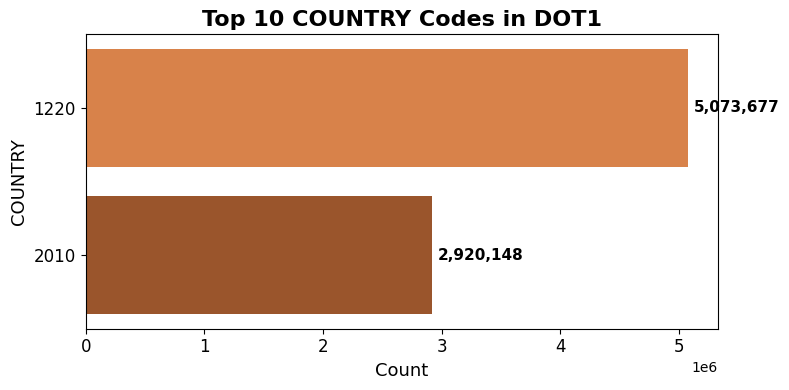

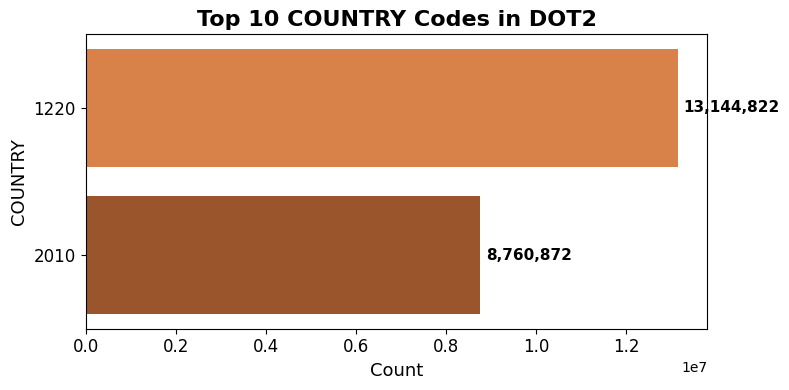

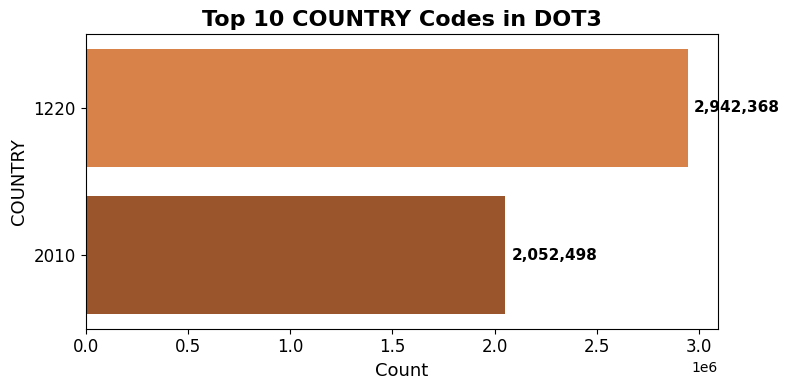

In [5]:
# Distribution of Country
plot_top_countries("deduped_dot1.csv", "DOT1")
plot_top_countries("deduped_dot2.csv", "DOT2")
plot_top_countries("deduped_dot3.csv", "DOT3")


In [6]:

def plot_top_DISAGMOT(file_path, label, top_n=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    country_counts = {}
    for chunk in pd.read_csv(file_path, usecols=['DISAGMOT'], dtype=str, chunksize=500_000):
        counts = chunk['DISAGMOT'].value_counts()
        for k, v in counts.items():
            country_counts[k] = country_counts.get(k, 0) + v

    s = pd.Series(country_counts).sort_values(ascending=False).head(top_n)
    df = s.reset_index()
    df.columns = ['DISAGMOT', 'Count']

    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=df, x='Count', y='DISAGMOT', hue='DISAGMOT', palette='Oranges_d', legend=False)

    for i, (val, name) in enumerate(zip(df['Count'], df['DISAGMOT'])):
        plt.text(val + max(df['Count']) * 0.01, i, f"{val:,}", va='center', fontsize=11, fontweight='bold')

    plt.title(f"Top {top_n} DISAGMOT Codes in {label}", fontsize=16, fontweight='bold')
    plt.xlabel("Count", fontsize=13)
    plt.ylabel("DISAGMOT", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()



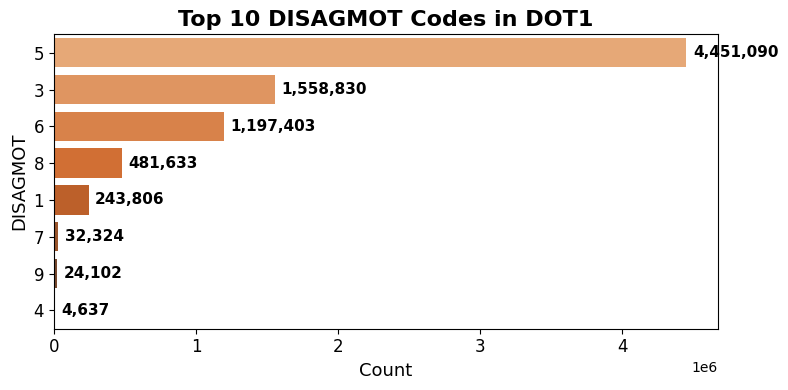

KeyboardInterrupt: 

In [7]:
# Distribution of DISAGMOT
plot_top_DISAGMOT("deduped_dot1.csv", "DOT1")
plot_top_DISAGMOT("deduped_dot2.csv", "DOT2")
plot_top_DISAGMOT("deduped_dot3.csv", "DOT3")


In [ ]:

def plot_top_Contcode(file_path, label, top_n=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    country_counts = {}
    for chunk in pd.read_csv(file_path, usecols=['CONTCODE'], dtype=str, chunksize=500_000):
        counts = chunk['CONTCODE'].value_counts()
        for k, v in counts.items():
            country_counts[k] = country_counts.get(k, 0) + v

    s = pd.Series(country_counts).sort_values(ascending=False).head(top_n)
    df = s.reset_index()
    df.columns = ['CONTCODE', 'Count']

    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=df, x='Count', y='CONTCODE', hue='CONTCODE', palette='Oranges_d', legend=False)

    for i, (val, name) in enumerate(zip(df['Count'], df['CONTCODE'])):
        plt.text(val + max(df['Count']) * 0.01, i, f"{val:,}", va='center', fontsize=11, fontweight='bold')

    plt.title(f"Top {top_n} CONTCODE Codes in {label}", fontsize=16, fontweight='bold')
    plt.xlabel("Count", fontsize=13)
    plt.ylabel("CONTCODE", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()



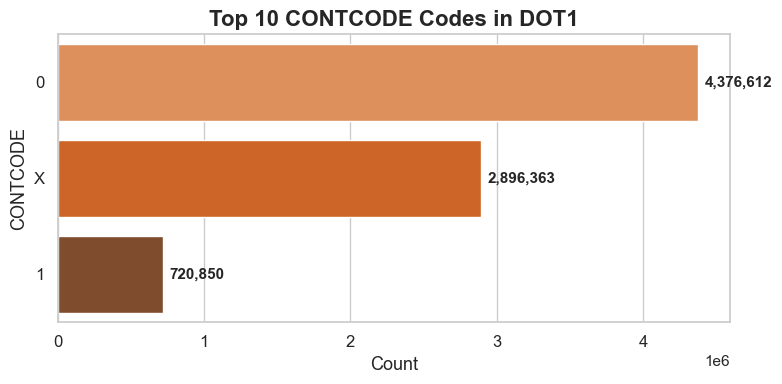

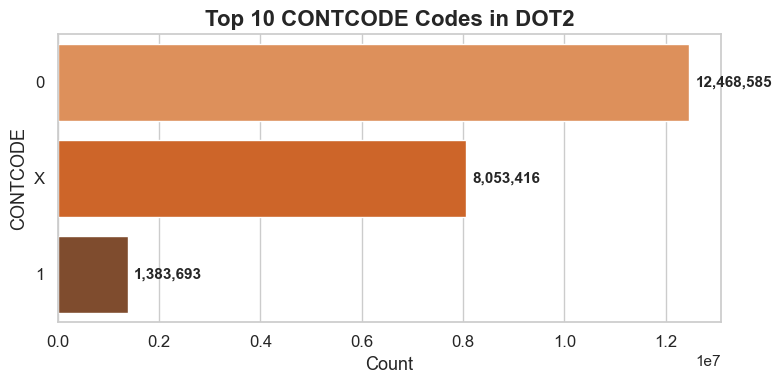

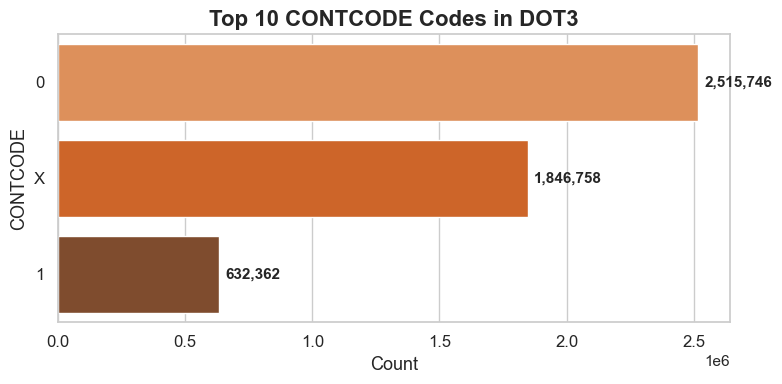

In [ ]:
# Distribution for CONTCODE
plot_top_Contcode("deduped_dot1.csv", "DOT1")
plot_top_Contcode("deduped_dot2.csv", "DOT2")
plot_top_Contcode("deduped_dot3.csv", "DOT3")


In [ ]:

def plot_top_Commodity2(file_path, label, top_n=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    country_counts = {}
    for chunk in pd.read_csv(file_path, usecols=['COMMODITY2'], dtype=str, chunksize=500_000):
        counts = chunk['COMMODITY2'].value_counts()
        for k, v in counts.items():
            country_counts[k] = country_counts.get(k, 0) + v

    s = pd.Series(country_counts).sort_values(ascending=False).head(top_n)
    df = s.reset_index()
    df.columns = ['COMMODITY2', 'Count']

    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=df, x='Count', y='COMMODITY2', hue='COMMODITY2', palette='Oranges_d', legend=False)

    for i, (val, name) in enumerate(zip(df['Count'], df['COMMODITY2'])):
        plt.text(val + max(df['Count']) * 0.01, i, f"{val:,}", va='center', fontsize=11, fontweight='bold')

    plt.title(f"Top {top_n} COMMODITY2 Codes in {label}", fontsize=16, fontweight='bold')
    plt.xlabel("Count", fontsize=13)
    plt.ylabel("COMMODITY2", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()



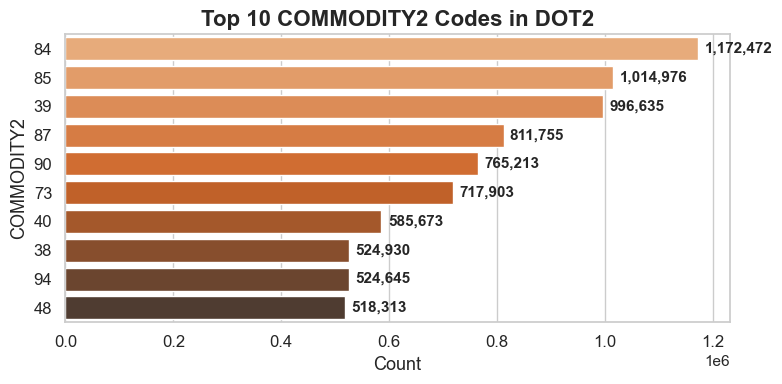

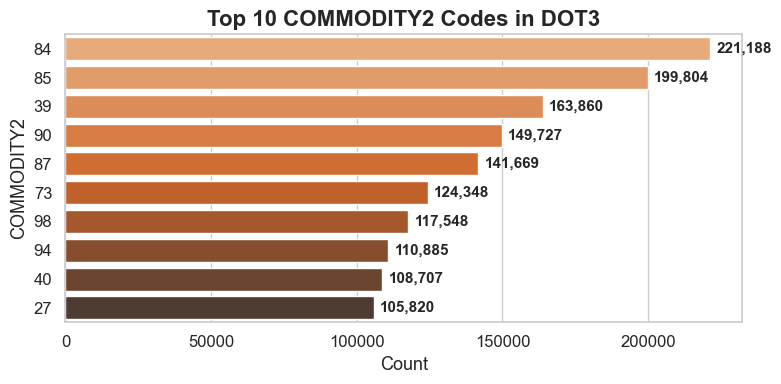

In [ ]:
# Distribution for COMMODITY2
plot_top_Commodity2("deduped_dot2.csv", "DOT2")
plot_top_Commodity2("deduped_dot3.csv", "DOT3")


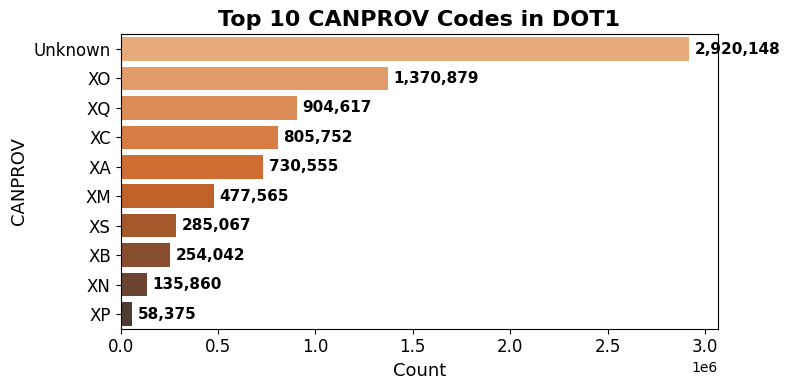

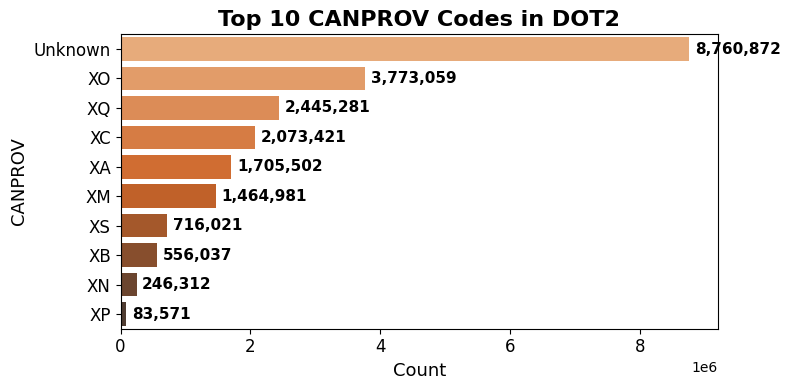

In [ ]:
# Distribution for CANPROV
def plot_top_canprov(file_path, label, top_n=10):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    country_counts = {}
    for chunk in pd.read_csv(file_path, usecols=['CANPROV'], dtype=str, chunksize=500_000):
        counts = chunk['CANPROV'].value_counts()
        for k, v in counts.items():
            country_counts[k] = country_counts.get(k, 0) + v

    s = pd.Series(country_counts).sort_values(ascending=False).head(top_n)
    df = s.reset_index()
    df.columns = ['CANPROV', 'Count']

    plt.figure(figsize=(8, 4))
    bars = sns.barplot(data=df, x='Count', y='CANPROV', hue='CANPROV', palette='Oranges_d', legend=False)

    for i, (val, name) in enumerate(zip(df['Count'], df['CANPROV'])):
        plt.text(val + max(df['Count']) * 0.01, i, f"{val:,}", va='center', fontsize=11, fontweight='bold')

    plt.title(f"Top {top_n} CANPROV Codes in {label}", fontsize=16, fontweight='bold')
    plt.xlabel("Count", fontsize=13)
    plt.ylabel("CANPROV", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_top_canprov("deduped_dot1.csv", "DOT1")
plot_top_canprov("deduped_dot2.csv", "DOT2")




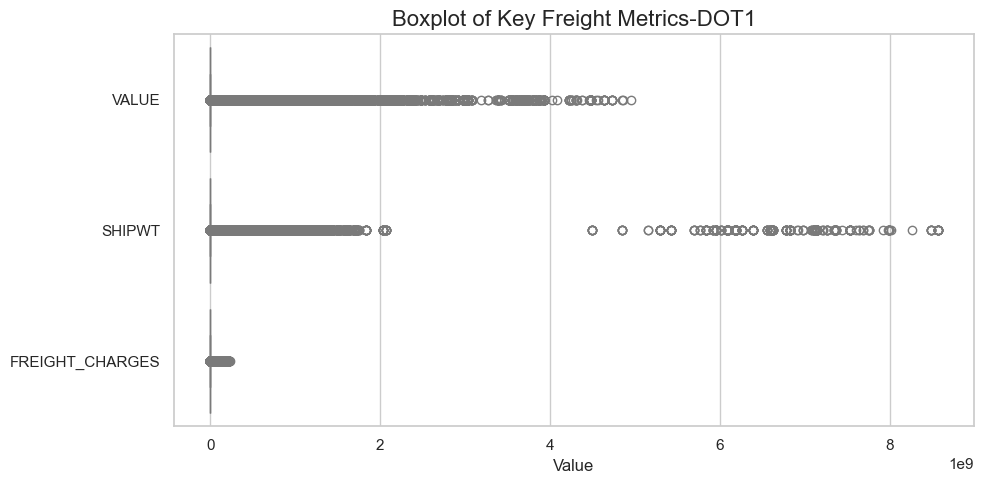

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
file_path = "deduped_dot1.csv"
numeric_cols = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES']
chunk_size = 500_000

# Aggregate chunks into memory-efficient list
data = {col: [] for col in numeric_cols}
for chunk in pd.read_csv(file_path, usecols=numeric_cols, dtype='float32', chunksize=chunk_size):
    for col in numeric_cols:
        data[col].extend(chunk[col].dropna().tolist())


# Convert to DataFrame for boxplot
df_numeric = pd.DataFrame(data)

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_numeric, orient='h', palette='Pastel1')
plt.title('Boxplot of Key Freight Metrics-DOT1', fontsize=16)
plt.xlabel('Value')
plt.tight_layout()
plt.show()


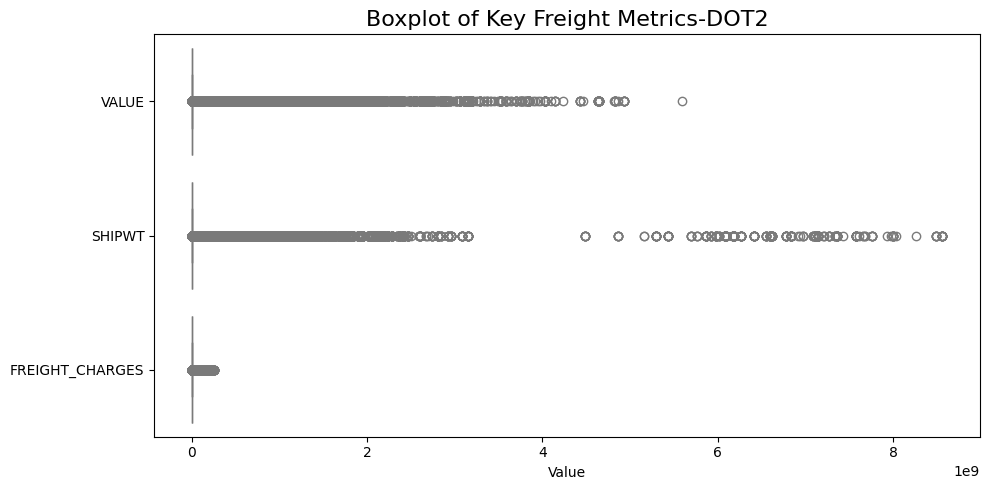

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
file_path = "deduped_dot2.csv"
numeric_cols = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES']
chunk_size = 500_000

# Aggregate chunks into memory-efficient list
data = {col: [] for col in numeric_cols}
for chunk in pd.read_csv(file_path, usecols=numeric_cols, dtype='float32', chunksize=chunk_size):
    for col in numeric_cols:
        data[col].extend(chunk[col].dropna().tolist())


# Convert to DataFrame for boxplot
df_numeric = pd.DataFrame(data)

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_numeric, orient='h', palette='Pastel1')
plt.title('Boxplot of Key Freight Metrics-DOT2', fontsize=16)
plt.xlabel('Value')
plt.tight_layout()
plt.show()


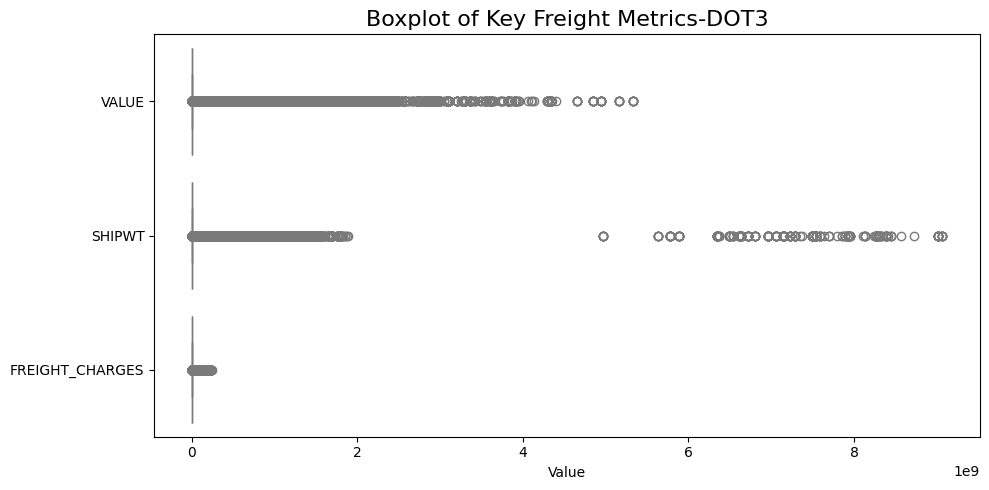

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
file_path = "deduped_dot3.csv"
numeric_cols = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES']
chunk_size = 500_000

# Aggregate chunks into memory-efficient list
data = {col: [] for col in numeric_cols}
for chunk in pd.read_csv(file_path, usecols=numeric_cols, dtype='float32', chunksize=chunk_size):
    for col in numeric_cols:
        data[col].extend(chunk[col].dropna().tolist())


# Convert to DataFrame for boxplot
df_numeric = pd.DataFrame(data)

# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_numeric, orient='h', palette='Pastel1')
plt.title('Boxplot of Key Freight Metrics-DOT3', fontsize=16)
plt.xlabel('Value')
plt.tight_layout()
plt.show()


Bivariate Analysis

DOT 1

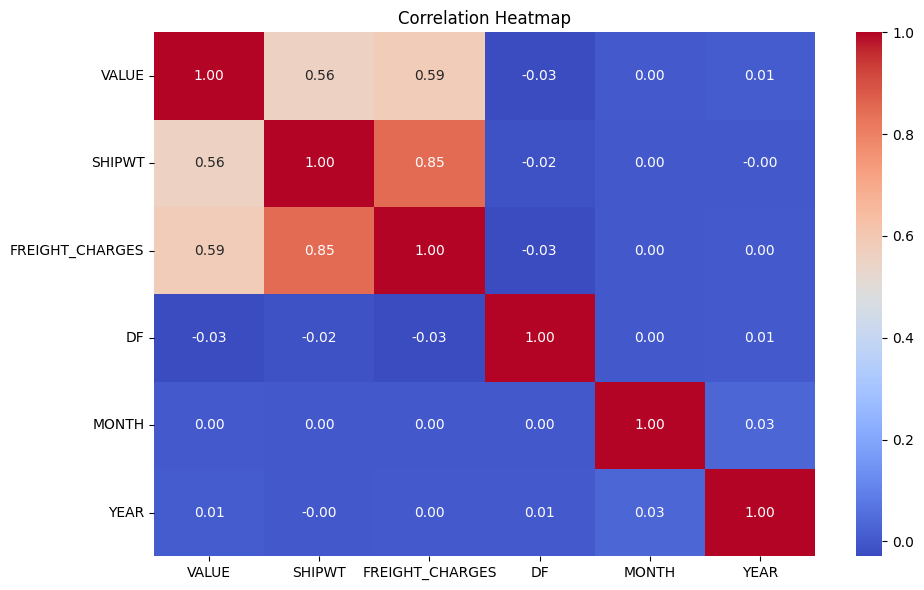

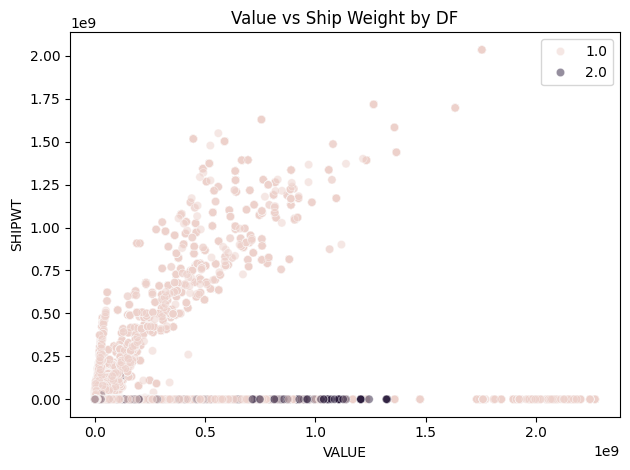

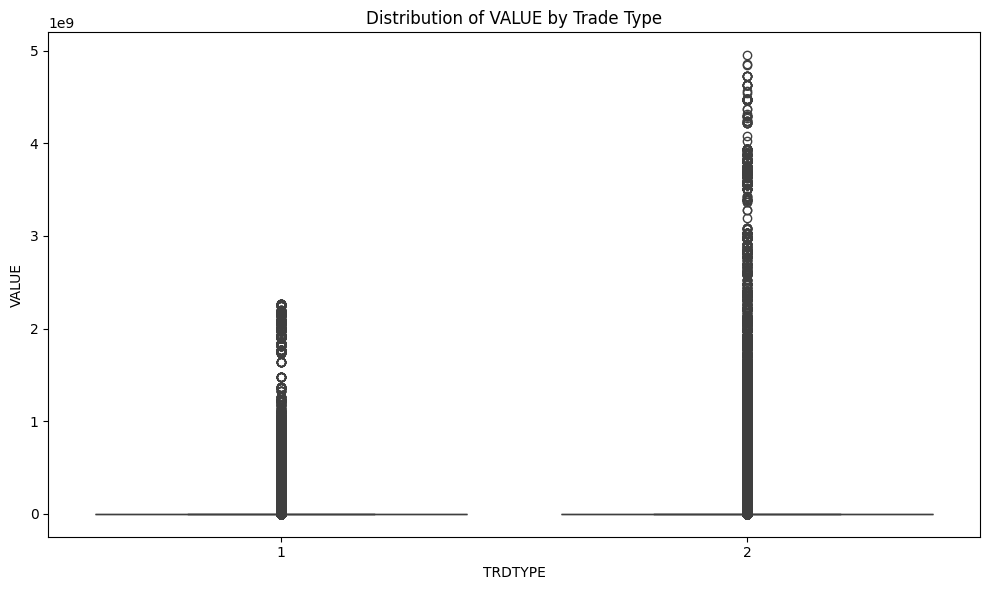

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace with the relevant dataset file
df = pd.read_csv('deduped_dot1.csv')  

# Convert categorical codes if needed
categorical_cols = ['TRDTYPE', 'USASTATE', 'MEXSTATE', 'CANPROV', 'COUNTRY', 'CONTCODE', 'SOURCE_FILE']
df[categorical_cols] = df[categorical_cols].astype('category')

#Correlation Heatmap

plt.figure(figsize=(10, 6))
numerics = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES', 'DF', 'MONTH', 'YEAR']
sns.heatmap(df[numerics].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


#Scatter plot
sns.scatterplot(data=df, x='VALUE', y='SHIPWT', hue='DF', alpha=0.5)
plt.title('Value vs Ship Weight by DF')
plt.legend(loc='upper right')  
plt.tight_layout()
plt.show()



#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='TRDTYPE', y='VALUE', data=df)
plt.title('Distribution of VALUE by Trade Type')
plt.tight_layout()
plt.show()


DOT 2

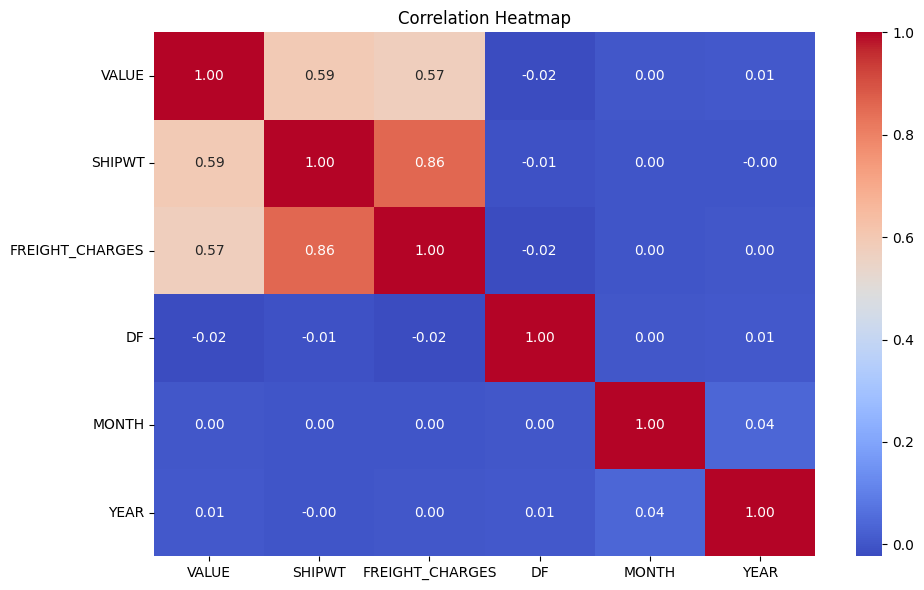

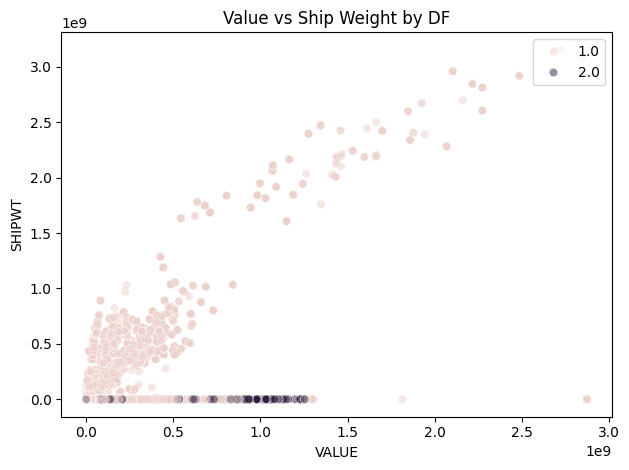

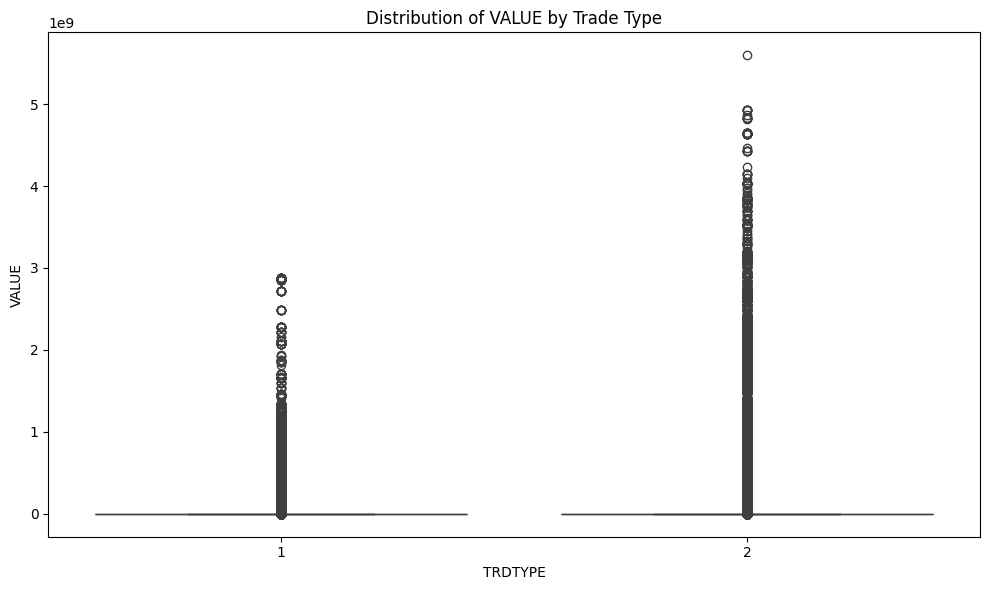

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace with the relevant dataset file
#df = pd.read_csv('deduped_dot2.csv') 
df = pd.read_csv('deduped_dot2.csv', dtype={'DEPE': str}, low_memory=False) 

# Convert categorical codes if needed
categorical_cols = ['TRDTYPE', 'USASTATE', 'MEXSTATE', 'CANPROV', 'COUNTRY', 'CONTCODE', 'SOURCE_FILE']
df[categorical_cols] = df[categorical_cols].astype('category')

#Correlation Heatmap

plt.figure(figsize=(10, 6))
numerics = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES', 'DF', 'MONTH', 'YEAR']
sns.heatmap(df[numerics].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


#Scatter plot
sns.scatterplot(data=df, x='VALUE', y='SHIPWT', hue='DF', alpha=0.5)
plt.title('Value vs Ship Weight by DF')
plt.legend(loc='upper right')  
plt.tight_layout()
plt.show()



#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='TRDTYPE', y='VALUE', data=df)
plt.title('Distribution of VALUE by Trade Type')
plt.tight_layout()
plt.show()


DOT 3

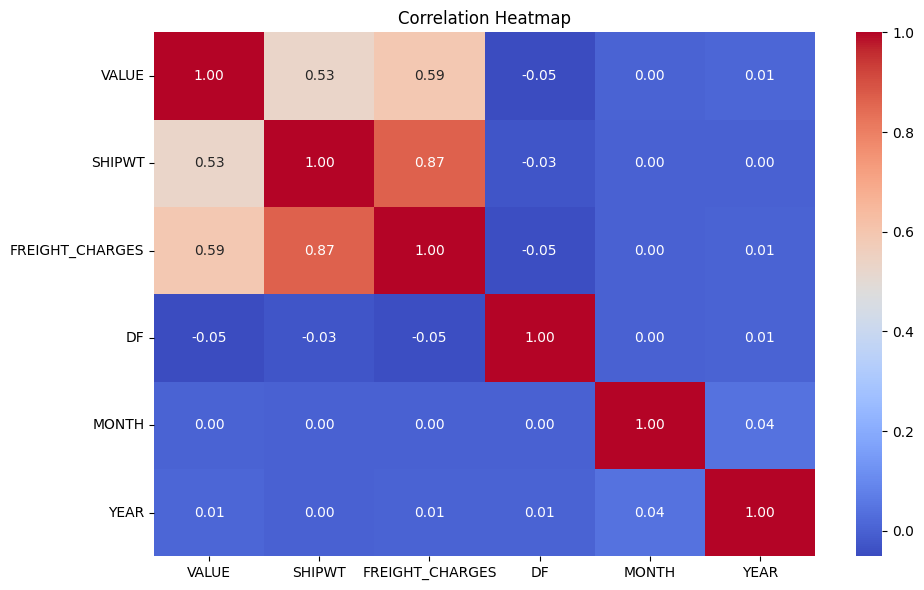

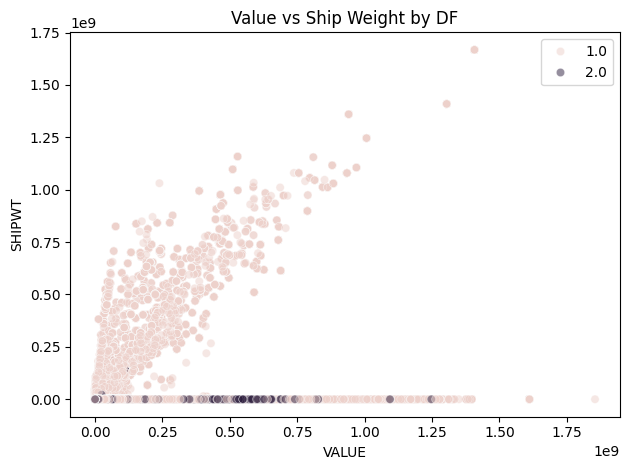

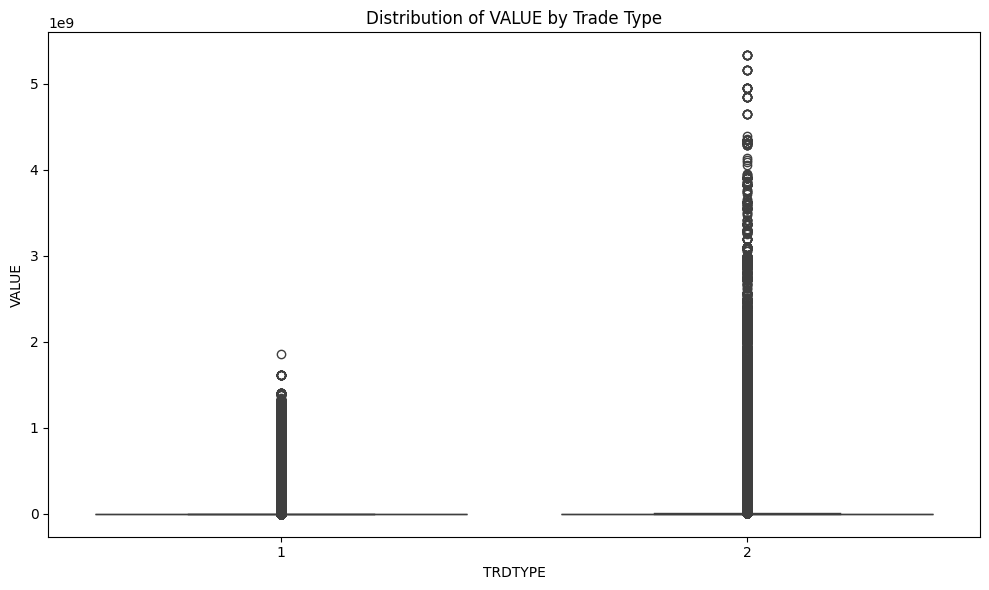

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace with the relevant dataset file
df = pd.read_csv('deduped_dot3.csv') 
#df = pd.read_csv('deduped_dot2.csv', dtype={'DEPE': str}, low_memory=False) 

# Convert categorical codes if needed
categorical_cols = ['TRDTYPE', 'USASTATE', 'MEXSTATE', 'CANPROV', 'COUNTRY', 'CONTCODE', 'SOURCE_FILE']
df[categorical_cols] = df[categorical_cols].astype('category')

#Correlation Heatmap

plt.figure(figsize=(10, 6))
numerics = ['VALUE', 'SHIPWT', 'FREIGHT_CHARGES', 'DF', 'MONTH', 'YEAR']
sns.heatmap(df[numerics].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


#Scatter plot
sns.scatterplot(data=df, x='VALUE', y='SHIPWT', hue='DF', alpha=0.5)
plt.title('Value vs Ship Weight by DF')
plt.legend(loc='upper right')  
plt.tight_layout()
plt.show()



#Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='TRDTYPE', y='VALUE', data=df)
plt.title('Distribution of VALUE by Trade Type')
plt.tight_layout()
plt.show()


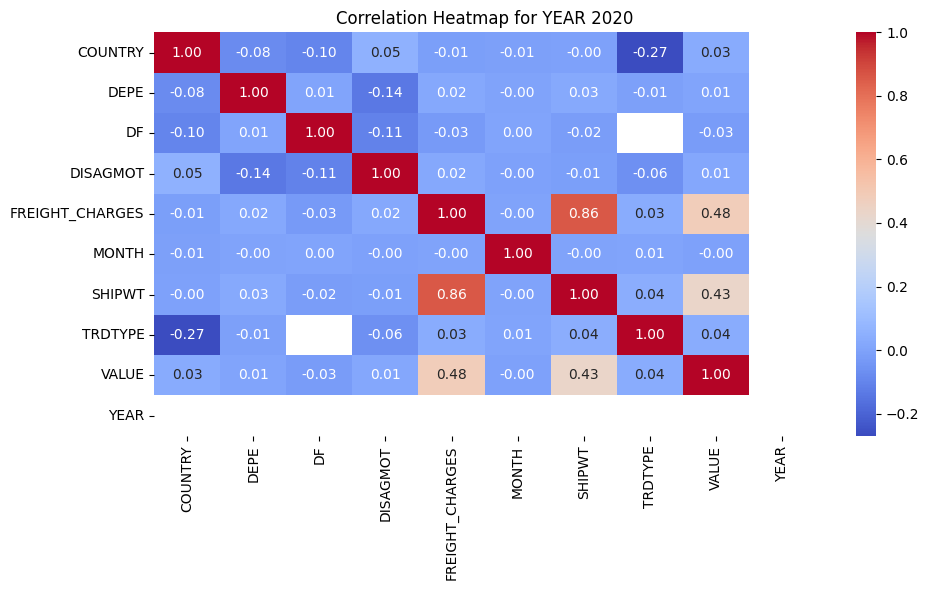

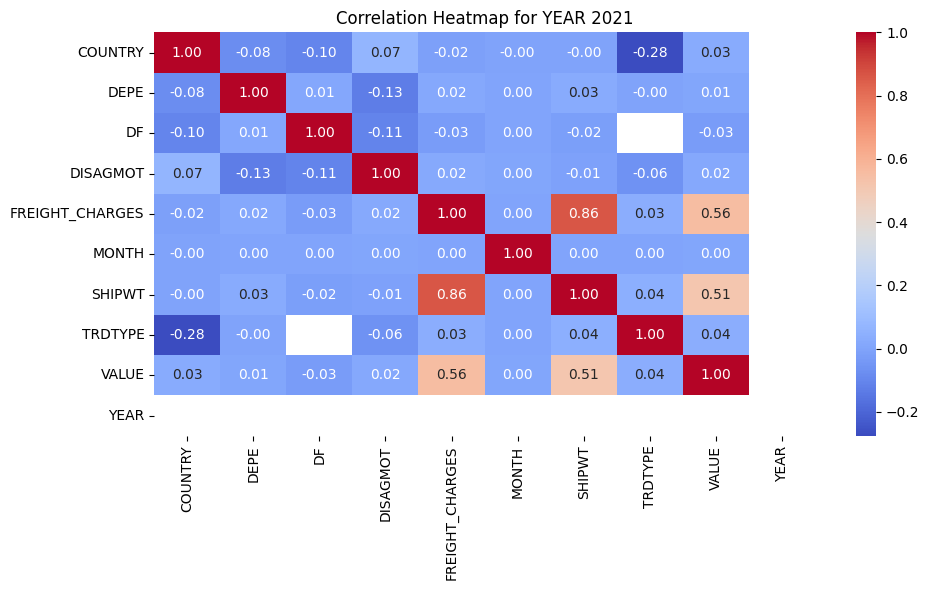

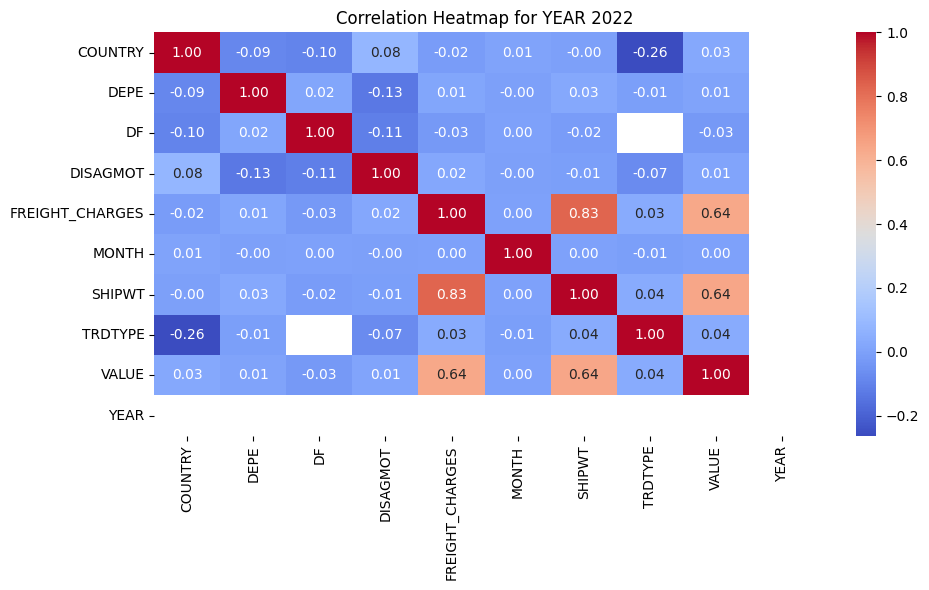

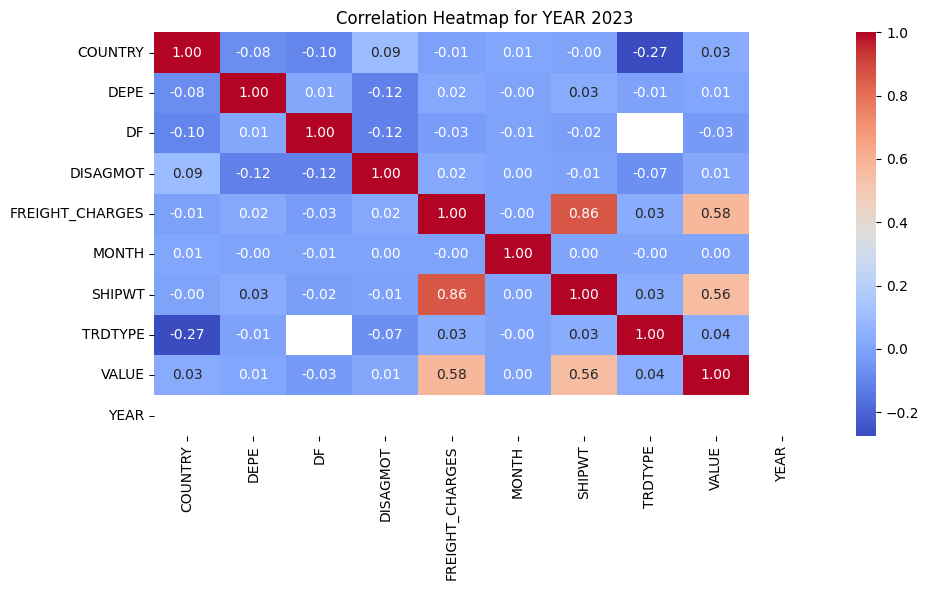

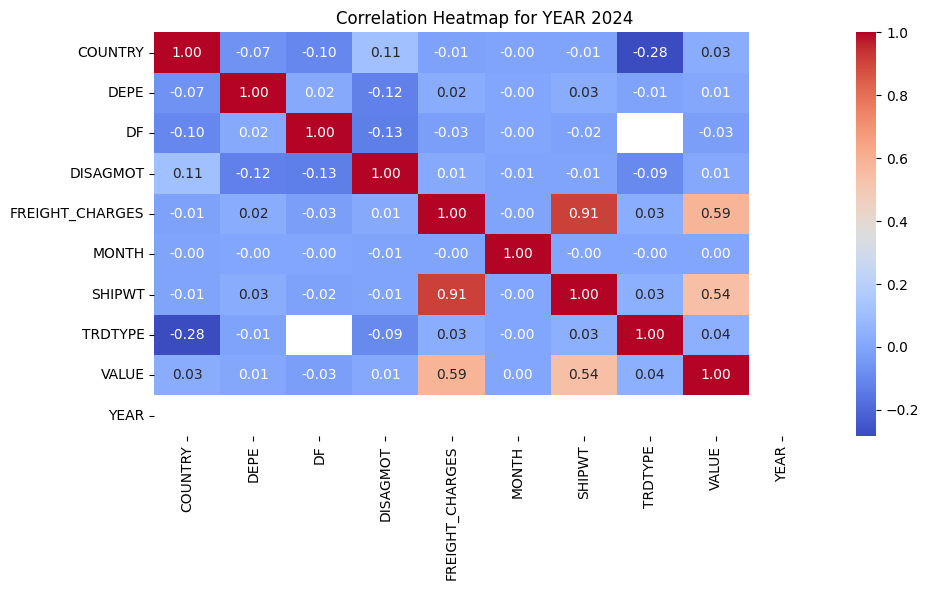

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('deduped_dot1.csv')  

# Correlation by YEAR (example)
for year in df['YEAR'].unique():
    subset = df[df['YEAR'] == year]
    numeric_cols = subset.select_dtypes(include='number')
    corr = numeric_cols.corr()

    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap for YEAR {year}')
    plt.tight_layout()
    plt.show()


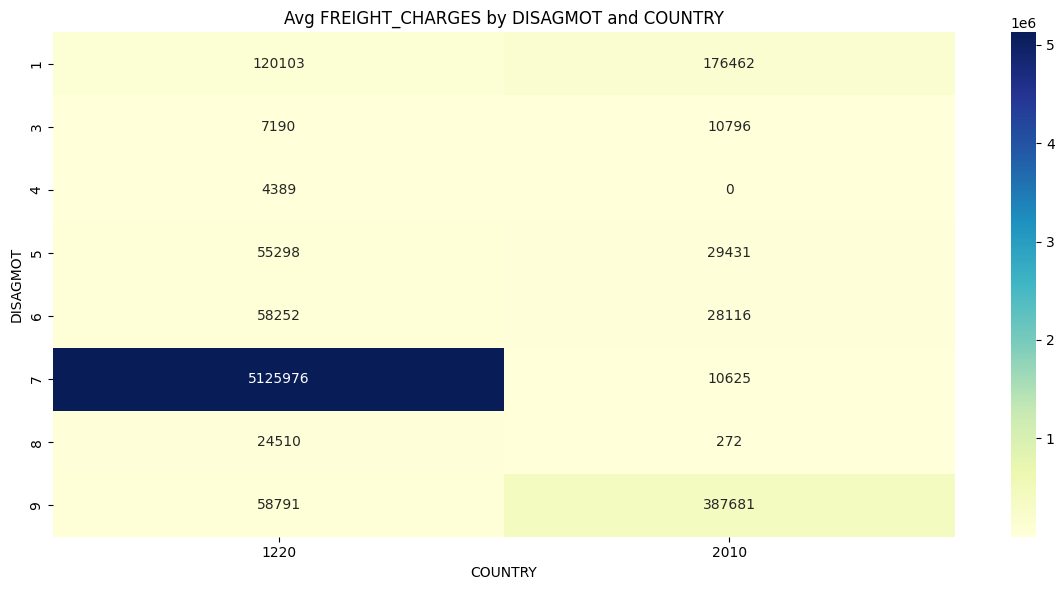

In [2]:
grouped = df.groupby(['DISAGMOT', 'COUNTRY'])['FREIGHT_CHARGES'].mean().reset_index()

plt.figure(figsize=(12, 6))
pivot = grouped.pivot(index='DISAGMOT', columns='COUNTRY', values='FREIGHT_CHARGES')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Avg FREIGHT_CHARGES by DISAGMOT and COUNTRY')
plt.ylabel('DISAGMOT')
plt.xlabel('COUNTRY')
plt.tight_layout()
plt.show()


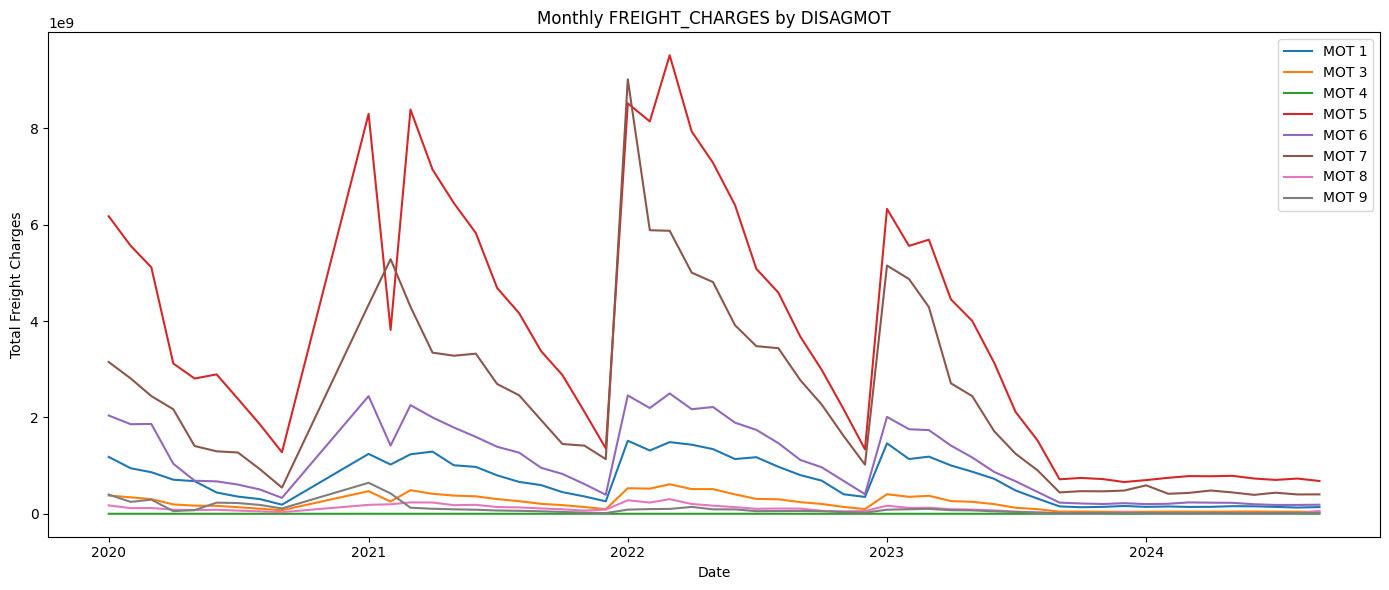

In [4]:
monthly = df.groupby(['YEAR', 'MONTH', 'DISAGMOT'])['FREIGHT_CHARGES'].sum().reset_index()
monthly['DATE'] = pd.to_datetime(monthly[['YEAR', 'MONTH']].assign(DAY=1))

plt.figure(figsize=(14, 6))
for mot in monthly['DISAGMOT'].unique():
    subset = monthly[monthly['DISAGMOT'] == mot]
    plt.plot(subset['DATE'], subset['FREIGHT_CHARGES'], label=f'MOT {mot}')

plt.legend()
plt.title('Monthly FREIGHT_CHARGES by DISAGMOT')
plt.ylabel('Total Freight Charges')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


KEY OBSERVATIONS FROM EDA:
1. Volume and Structure
The three datasets (dot1, dot2, dot3) contain consistent core columns (VALUE, SHIPWT, FREIGHT_CHARGES, DF, TRDTYPE, DISAGMOT, COUNTRY, MONTH, YEAR) but differ in auxiliary columns like COMMODITY2, USASTATE, MEXSTATE

2. Univariate Distributions
- VALUE, SHIPWT, and FREIGHT_CHARGES are right-skewed, with a concentration of lower values and few high outliers.

- YEAR and MONTH distributions confirm good temporal coverage 

3. Categorical Counts
- Dominant countries: U.S., Canada, and Mexico.

- DISAGMOT (mode of transport) and TRDTYPE (trade type) show modal dominance 

4. Bivariate Insights
Positive correlations among VALUE, SHIPWT, and FREIGHT_CHARGES as expected.